# Trajectory Cache Backend Benchmark

Comparison of four trajectory-cache backends as approximate-nearest-neighbor
(ANN) search structures over MoveIt `PlanRequest`s.

Each request is reduced to a feature vector (joint angles, optionally pose),
and the cache returns any previously-planned trajectory whose stored request
lies within configured per-coordinate tolerances of the query.

Workflow per backend:

1. **Collect phase** — sample random goals around `idle`, plan & execute
   `idle -> goal -> idle` until 25 round-trips succeed.
2. **Cycle phase** — replay the same successful goals 5 times. A working
   cache should hit on every leg after the first cycle.

Per leg we log: plan/query time, execution time, and whether the trajectory
came from the cache (`from_cache`) or was planned fresh.

In [1]:
import os

import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import pandas as pd

In [2]:
CSV_PATH = os.path.expandvars("$TABLETOP_CACHE_DIR/cache_benchmark.csv")
FIGURE_DIR = os.path.expandvars("$TABLETOP_CACHE_DIR/figures")
BACKEND_RENAME = {
    "lmdb": "spatial_bin_lmdb",
    "dict": "spatial_bin",
    "linear": "brute_force",
    "kdtree": "kdtree",
}
BACKEND_ORDER = ["spatial_bin_lmdb", "spatial_bin", "brute_force", "kdtree"]
BACKEND_COLORS = {
    "spatial_bin_lmdb": "#1f77b4",
    "spatial_bin": "#aec7e8",
    "brute_force": "#2ca02c",
    "kdtree": "#ff7f0e",
}

df = pd.read_csv(CSV_PATH)
df = df[df["success"]].reset_index(drop=True)
df["backend"] = df["backend"].map(BACKEND_RENAME)
df["plan_time_ms"] = df["plan_time_s"] * 1000

print(f"Loaded {len(df)} successful legs from {CSV_PATH}")
display(df.describe())
display(df)

Loaded 14343 successful legs from /tabletop/.cache/tabletop/cache_benchmark.csv


,cycle,goal_idx,cache_size,plan_time_s,exec_time_s,plan_time_ms
count,14343.000000,14343.00000,14343.000000,14343.000000,14343.000000,14343.000000
mean,1.665691,149.59841,1968.324549,0.004766,0.202653,4.765623
std,1.490779,86.56209,1067.359532,0.002331,0.015230,2.331241
min,0.000000,0.00000,0.000000,0.001926,0.000555,1.926000
25%,0.000000,75.00000,1288.000000,0.003521,0.204077,3.521000
50%,1.000000,150.00000,1308.000000,0.004313,0.204496,4.313000
75%,3.000000,225.00000,3029.000000,0.005668,0.205096,5.667500
max,4.000000,299.00000,4010.000000,0.204453,0.257042,204.453000


,backend,phase,cycle,goal_idx,goal_type,direction,from_cache,cache_size,plan_time_s,exec_time_s,success,error,plan_time_ms
0,spatial_bin_lmdb,collect,0,0,robot_state,to_goal,False,9,0.204453,0.253946,True,NaN,204.453
1,spatial_bin_lmdb,collect,0,0,robot_state,to_idle,False,13,0.002823,0.203810,True,NaN,2.823
2,spatial_bin_lmdb,collect,0,1,robot_state,to_goal,False,17,0.003439,0.203896,True,NaN,3.439
3,spatial_bin_lmdb,collect,0,1,robot_state,to_idle,True,21,0.003692,0.203422,True,NaN,3.692
4,spatial_bin_lmdb,collect,0,2,pose,to_goal,False,21,0.003829,0.203795,True,NaN,3.829
...,...,...,...,...,...,...,...,...,...,...,...,...,...
14338,kdtree,cycle,4,297,robot_state,to_idle,True,1308,0.004051,0.204945,True,NaN,4.051
14339,kdtree,cycle,4,298,robot_state,to_goal,True,1308,0.003893,0.205836,True,NaN,3.893
14340,kdtree,cycle,4,298,robot_state,to_idle,True,1308,0.004591,0.203071,True,NaN,4.591
14341,kdtree,cycle,4,299,robot_state,to_goal,True,1308,0.004544,0.204480,True,NaN,4.544


## Backend overview

All four backends implement the same `Mapping`-like API
(`__setitem__` / `__getitem__` / `__contains__` / `__delitem__`) over
`PlanRequest -> RobotTrajectory`. They differ only in how they index
the request space.

Notation: `N` = entries in the cache, `B` = candidate trajectories per
match group (bounded by `max_trajectories`), `d` = feature-vector
dimensionality (12 or 13).

### spatial_bin_lmdb (`LMDBFuzzyTrajectoryCache`)

- **Concept.** Quantize every float coordinate of the request fingerprint
  via `int(x // tolerance)` to produce a deterministic integer-bin key.
  JSON-encode the bin dict and use the resulting bytes as an LMDB key.
  Each bin holds up to `B` candidates sorted by `path_cost`.
- **Update.** `O(log B)` to bisect-insert into the per-bin sorted list,
  plus one LMDB write transaction (disk I/O).
- **Query.** `O(1)` hash lookup on the bytes key + `O(B)` to read the
  ranked candidates.
- **Space.** `O(U)` on disk, where `U` is the number of distinct fuzzy
  bins ever populated.
- **Caveat.** *Bin-boundary aliasing* — coordinates that fall near
  `k * tolerance` toggle into adjacent bins under tiny floating-point
  drift, so the same physical request can produce different keys across
  runs.

### spatial_bin (`DictFuzzyTrajectoryCache`)

- **Concept.** Identical indexing strategy to spatial_bin_lmdb, but the bin map is a
  Python `dict` instead of an LMDB env. The dict is pickled on `close()`
  and unpickled on `open()`.
- **Update.** `O(log B)` bisect-insert (no per-operation disk I/O during
  the session — only on `close()`).
- **Query.** `O(1)` Python `dict` lookup + `O(B)` to read candidates.
- **Space.** `O(U)` in memory + `O(U)` on disk after `close()`.
- **Caveat.** Same bin-boundary aliasing as spatial_bin_lmdb.

### brute_force (`LinearTrajectoryCache`)

- **Concept.** Store each request fingerprint verbatim (no quantization).
  On query, scan **every** stored fingerprint and apply per-coordinate
  tolerance checks `|x_i - y_i| <= tolerance_i`.
- **Update.** `O(1)` amortized — dict insertion under the exact JSON-bytes
  fingerprint (byte-identical duplicates merge, near-but-not-identical
  ones don't).
- **Query.** `O(N \cdot d)` — full scan, comparing `d` coordinates per
  entry.
- **Space.** `O(N)`.
- **Strength.** Recall is exactly the configured tolerance — no aliasing.
- **Weakness.** Query cost grows linearly with cache size; the brute-force
  baseline an ANN structure should beat.

### K-d tree cache (`KDTreeTrajectoryCache`)

- **Concept.** Map each request to a 12-D feature vector (joint-space
  goals: 6 start joints ++ 6 goal joints) or 13-D (Cartesian goals: 6
  start joints ++ 3 position ++ 4 quaternion). Pre-scale each coordinate
  by `1 / tolerance` so the per-coordinate tolerance becomes a unit-radius
  L∞ ball. Build two scipy `KDTree`s (one per goal-type dimensionality)
  and query with `query_ball_point(scaled_query, r=1, p=np.inf)`.
- **Update.** `O(1)` amortized — append to the feature list; tree rebuild
  is deferred until the next query.
- **Query.** `O(\log N + k)` for a balanced ball query (`k` = matches),
  plus one `O(N \log N)` rebuild whenever the tree is stale.
- **Space.** `O(N \cdot d)` for features + `O(N)` for the tree.
- **Strength.** Preserves exact per-coordinate tolerance semantics (no
  aliasing) while achieving sublinear average-case query time.

## Plot 1 — Cache hit rate by backend and phase

The headline benchmark number: of all the legs the cache **could have**
served from memory, what fraction did it actually find?

- **Collect phase**: first-time visits. The reverse-trajectory caching
  (`cache_trajectory(_reverse=True)`) stores the return leg alongside the
  outbound one, so the return leg of each round-trip should be a cache hit
  — giving a theoretical ceiling around 50%. This assumes the stored and
  queried keys match; for spatial-bin backends, bin-boundary aliasing at
  the idle position can break this match (see takeaway below).
- **Cycle phase**: replays. Every leg should be a cache hit — the cache
  has seen this exact (start, goal) pair before.

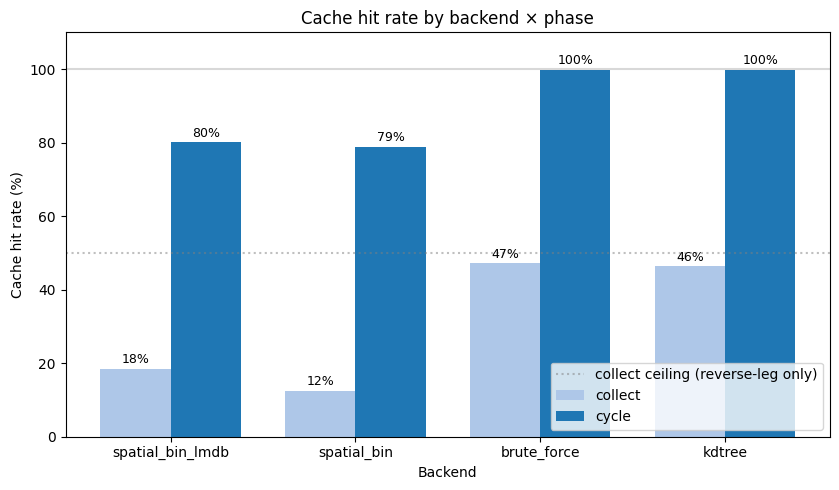

In [3]:
hit_rate = (
    df.groupby(["backend", "phase"])["from_cache"].mean() * 100
).unstack(level="phase")
hit_rate = hit_rate.reindex(BACKEND_ORDER)[["collect", "cycle"]]

fig, ax = plt.subplots(figsize=(8.5, 5))
x = np.arange(len(BACKEND_ORDER))
w = 0.38
ax.bar(
    x - w / 2, hit_rate["collect"], width=w, label="collect", color="#aec7e8"
)
ax.bar(x + w / 2, hit_rate["cycle"], width=w, label="cycle", color="#1f77b4")
for i, b in enumerate(BACKEND_ORDER):
    ax.text(
        i - w / 2,
        hit_rate.loc[b, "collect"] + 1.5,  # type: ignore
        f"{hit_rate.loc[b, 'collect']:.0f}%",
        ha="center",
        fontsize=9,
    )
    ax.text(
        i + w / 2,
        hit_rate.loc[b, "cycle"] + 1.5,  # type: ignore
        f"{hit_rate.loc[b, 'cycle']:.0f}%",
        ha="center",
        fontsize=9,
    )
ax.set_xticks(x)
ax.set_xticklabels(BACKEND_ORDER)
ax.set_ylabel("Cache hit rate (%)")
ax.set_xlabel("Backend")
ax.set_ylim(0, 110)
ax.axhline(
    50,
    color="gray",
    linestyle=":",
    alpha=0.5,
    label="collect ceiling (reverse-leg only)",
)
ax.axhline(100, color="gray", linestyle="-", alpha=0.3)
ax.legend(loc="lower right")
ax.set_title("Cache hit rate by backend × phase")
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "plot1.png"), bbox_inches="tight")
plt.show()

**Takeaway.** The four backends split into two groups.

`brute_force` (~47%) and `kdtree` (~46%) land close to the 50% collect
ceiling — reverse-trajectory caching hits roughly half the legs as
expected. In the cycle phase both stay near **100%**, confirming exact
per-coordinate recall.

`spatial_bin` (~13%) and `spatial_bin_lmdb` (~19%) fall well below the
ceiling in collect, and **never reach 100% in the cycle phase** — climbing
from 61%/69% in cycle 1 to 90%/86% by cycle 5, but without converging.

The shortfall is **bin-boundary aliasing at zero-valued joints**: the
arm's idle position holds several joints at exactly 0 rad. The
quantization `int(0 // tolerance)` is numerically unstable — tiny
floating-point drift across zero flips the bin key between 0 and −1. A
trajectory stored under one key is invisible to a query that hashes to
the other, so misses persist even for goal positions the cache has seen
before.

## Plot 2 — Plan / query time distribution: hit vs miss

How much cheaper is a cache hit than a fresh plan? In a typical production
scenario with a slow planner the gap would be large — but this benchmark
uses a fast planner to keep the total run time manageable, so the hit and
miss distributions may overlap or even invert. The log scale is kept for
consistency with the direct benchmark (Part 2), where the gap is real.

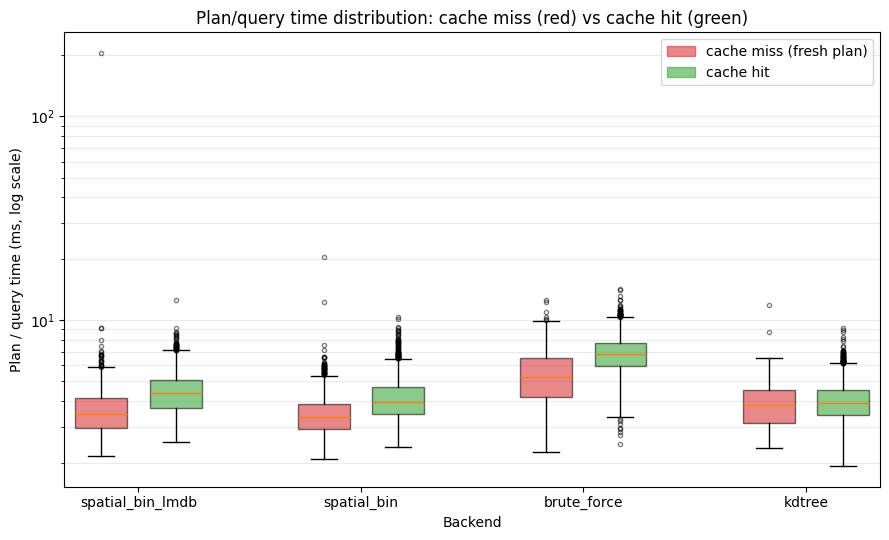

In [4]:
fig, ax = plt.subplots(figsize=(9, 5.5))
positions: list[float] = []
tick_pos: list[float] = []
tick_labels: list[str] = []
data: list[np.ndarray] = []
colors: list[str] = []
for i, backend in enumerate(BACKEND_ORDER):
    for j, hit in enumerate([False, True]):
        d = df.loc[
            (df.backend == backend) & (df.from_cache == hit), "plan_time_ms"
        ].values
        if len(d) == 0:
            continue
        pos = i * 3 + j
        positions.append(pos)
        data.append(d)  # type: ignore
        colors.append("#d62728" if not hit else "#2ca02c")
    tick_pos.append(i * 3 + 0.5)
    tick_labels.append(backend)

bp = ax.boxplot(
    data,
    positions=positions,
    widths=0.7,
    patch_artist=True,
    showfliers=True,
    flierprops={"marker": ".", "alpha": 0.5},
)
for patch, c in zip(bp["boxes"], colors):
    patch.set_facecolor(c)
    patch.set_alpha(0.55)
ax.set_xticks(tick_pos)
ax.set_xticklabels(tick_labels)
ax.set_yscale("log")
ax.set_ylabel("Plan / query time (ms, log scale)")
ax.set_xlabel("Backend")
ax.set_title(
    "Plan/query time distribution: cache miss (red) vs cache hit (green)"
)
ax.grid(axis="y", which="both", alpha=0.25)

ax.legend(
    handles=[
        mpatches.Patch(
            color="#d62728", alpha=0.55, label="cache miss (fresh plan)"
        ),
        mpatches.Patch(color="#2ca02c", alpha=0.55, label="cache hit"),
    ],
    loc="upper right",
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "plot2.png"), bbox_inches="tight")
plt.show()

**Takeaway.** With the fast planner used in this benchmark, cache hits
are **not** substantially cheaper than fresh plans — hit and miss
distributions overlap for every backend, and for *every* backend the
median hit is in fact slightly slower than the median miss (all-phase
medians):

- `spatial_bin`: miss 3.33 ms → hit 3.99 ms (+0.66 ms)
- `spatial_bin_lmdb`: miss 3.46 ms → hit 4.37 ms (+0.91 ms)
- `kdtree`: miss 3.84 ms → hit 3.92 ms (+0.08 ms)
- `brute_force`: miss 5.25 ms → hit 6.80 ms (+1.54 ms)

For the spatial/k-d backends, the extra cost is cache deserialization +
validation. For `brute_force` the gap is larger because most hits happen
in the cycle phase (cache fully populated, ~1 300 entries) while most
misses happen in the collect phase (cache still growing) — and
`brute_force`'s O(N·d) scan grows with N, so hits at larger N are
intrinsically slower than misses at smaller N.

The fast planner is **intentional** — it keeps total benchmark runtime
manageable — but it makes this plot a poor proxy for production value. In
a real workload with complex plans (often seconds each), the speedup from
a cache hit would dwarf lookup overhead. The direct benchmark (Part 2)
isolates cache latency cleanly, without the planner in the loop.

## Plot 3 — Cumulative plan / query time

Wall-clock view: as the experiment progresses, how much time has the
robot spent in planning + cache lookups for each backend?

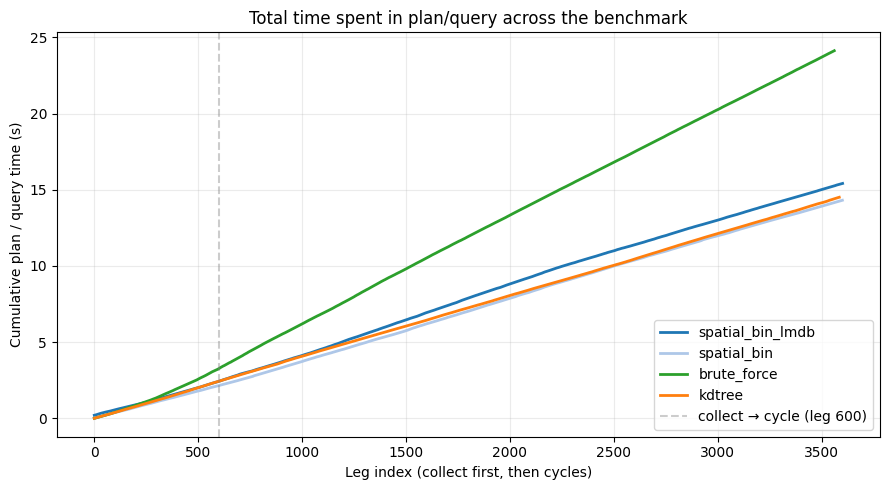

In [5]:
fig, ax = plt.subplots(figsize=(9, 5))
for backend in BACKEND_ORDER:
    d = df[df.backend == backend].reset_index(drop=True)
    cum = d.plan_time_s.cumsum()
    ax.plot(
        d.index + 1, cum, label=backend, color=BACKEND_COLORS[backend], lw=2
    )

# Mark the collect/cycle phase boundary per backend (same for all if
# `n_unique_goals * 2` collect legs).
lengths = df.groupby("backend")["phase"].value_counts().unstack().fillna(0)
if "collect" in lengths.columns:
    collect_n = int(lengths["collect"].iloc[0])
    ax.axvline(
        collect_n,
        color="gray",
        linestyle="--",
        alpha=0.4,
        label=f"collect → cycle (leg {collect_n})",
    )
ax.set_xlabel("Leg index (collect first, then cycles)")
ax.set_ylabel("Cumulative plan / query time (s)")
ax.set_title("Total time spent in plan/query across the benchmark")
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "plot3.png"), bbox_inches="tight")
plt.show()

**Takeaway.** After the collect/cycle boundary the slopes diverge.
`brute_force` carries the **steepest slope** into the cycle phase despite
its ~99.8% hit rate: its O(N·d) full scan runs on every `plan()` call
(hit or miss), adding ~7 ms per leg regardless of outcome — making it the
slowest backend per cycle (~4.1 s for 300 legs). `kdtree` and
`spatial_bin` are fastest (~2.4 s per cycle). `spatial_bin_lmdb` sits
slightly higher (~2.6 s) due to LMDB read-transaction overhead per hit.

The `spatial_bin` backends also continue accumulating cost through replay
cycles because ~10–40% of their legs still miss, triggering full OMPL
plans — a direct consequence of the bin-boundary aliasing that prevents
them from reaching 100% cycle hit rate.

## Plot 4 — Hit rate by replay cycle

Does cache hit rate improve as the experiment repeats the same goal
sequence, or is the gap fixed by the indexing strategy?

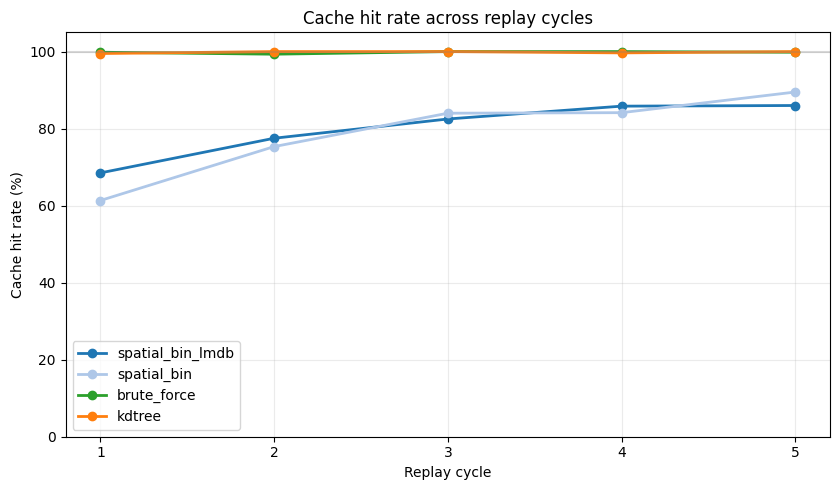

In [6]:
cyc = df[df.phase == "cycle"].copy()
hr = (cyc.groupby(["backend", "cycle"])["from_cache"].mean() * 100).unstack(
    level="backend"
)
hr = hr[BACKEND_ORDER]

fig, ax = plt.subplots(figsize=(8.5, 5))
for backend in BACKEND_ORDER:
    ax.plot(
        hr.index + 1,
        hr[backend],
        marker="o",
        lw=2,
        color=BACKEND_COLORS[backend],
        label=backend,
    )
ax.set_xlabel("Replay cycle")
ax.set_ylabel("Cache hit rate (%)")
ax.set_xticks(hr.index + 1)
ax.set_ylim(0, 105)
ax.set_title("Cache hit rate across replay cycles")
ax.axhline(100, color="gray", linestyle="-", alpha=0.3)
ax.legend()
ax.grid(alpha=0.25)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "plot4.png"), bbox_inches="tight")
plt.show()

**Takeaway.** `brute_force` and `kdtree` hit ~100% from cycle 1 and hold
there — exact per-coordinate tolerance matching finds stored trajectories
reliably every replay.

`spatial_bin` and `spatial_bin_lmdb` **never converge**: starting at 61%
and 69% respectively, they improve steadily across cycles (reaching 90%
and 86% by cycle 5), but cannot saturate. Bin-boundary aliasing creates a
self-reinforcing dynamic: each missed leg is planned fresh and re-inserted
under the new aliased bin key, gradually broadening coverage (hence the
upward trend) — but joints permanently near 0 rad continue to hash
inconsistently, so some fraction of goals remain unreachable by the cache
regardless of how many times they have been stored.

## Plot 5 — Cache-hit query time vs cache size

Does lookup overhead scale with the number of stored entries? This is the
algorithmic question that separates O(1) hash-based backends from O(N)
linear scan and O(log N) k-d tree.

Each point is a **cache hit** — miss rows go to the OMPL planner and do not
exercise the cache lookup path. `cache_size` is captured immediately before
each `plan()` call, so it reflects the state of the index at lookup time,
before any new insertion from that leg.

> **Note on `len()` semantics**: for `spatial_bin_lmdb` and `spatial_bin`,
> `__len__` counts quantized *bins*; for `brute_force` it counts exact
> fingerprints; for `kdtree` it counts total stored feature vectors (state
> + pose trees combined). Each insert normally produces up to 4 bins
> (forward/reverse × joint/pose), so 300 goals → ~1 200 baseline entries.
> Bin-boundary aliasing inflates this further for `spatial_bin_lmdb` and
> `spatial_bin`, pushing their reported sizes to ~3 000–4 000.

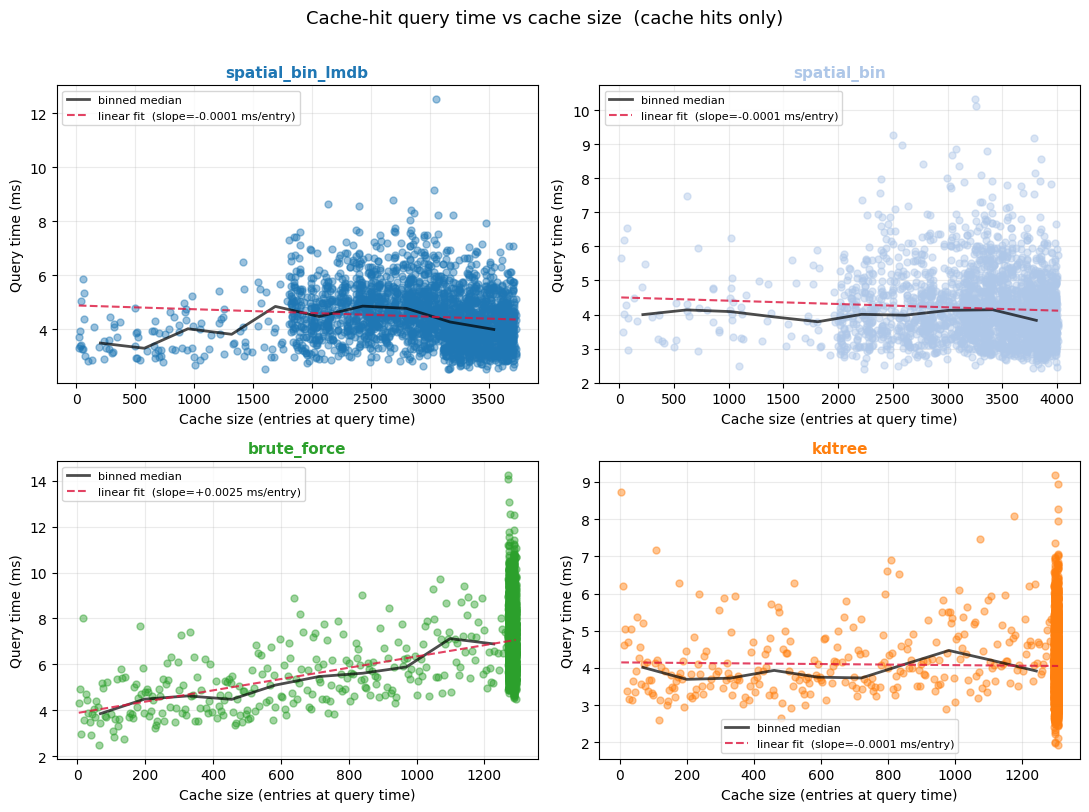

In [7]:
hits = df[df["from_cache"] == True].copy()

fig, axes = plt.subplots(2, 2, figsize=(11, 8))
axes = axes.flatten()

for ax, backend in zip(axes, BACKEND_ORDER):
    d = hits[hits["backend"] == backend].sort_values("cache_size")
    color = BACKEND_COLORS[backend]

    ax.scatter(
        d["cache_size"],
        d["plan_time_ms"],
        alpha=0.45,
        s=25,
        color=color,
        zorder=3,
    )

    # Binned median — smooths over system-noise scatter
    if d["cache_size"].nunique() >= 3:
        bins = pd.cut(
            d["cache_size"],
            bins=min(10, d["cache_size"].nunique()),
            include_lowest=True,
        )
        binned = d.groupby(bins, observed=True)["plan_time_ms"].median()
        bin_centers = [iv.mid for iv in binned.index]
        ax.plot(
            bin_centers,
            binned.values,
            color="black",
            lw=2,
            alpha=0.7,
            zorder=4,
            label="binned median",
        )

    # Linear regression trend line
    if len(d) >= 3:
        z = np.polyfit(d["cache_size"], d["plan_time_ms"], 1)
        xs = np.linspace(d["cache_size"].min(), d["cache_size"].max(), 100)
        ax.plot(
            xs,
            np.polyval(z, xs),
            color="crimson",
            lw=1.5,
            linestyle="--",
            alpha=0.8,
            zorder=5,
            label=f"linear fit  (slope={z[0]:+.4f} ms/entry)",
        )

    ax.set_title(backend, fontsize=11, color=color, fontweight="bold")
    ax.set_xlabel("Cache size (entries at query time)")
    ax.set_ylabel("Query time (ms)")
    ax.legend(fontsize=8)
    ax.grid(alpha=0.25)

fig.suptitle(
    "Cache-hit query time vs cache size  (cache hits only)",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "plot5.png"), bbox_inches="tight")
plt.show()

**Takeaway.** The cache sizes themselves tell the aliasing story.
`brute_force` and `kdtree` stabilise near **1 292 and 1 308 entries**
respectively — consistent with 300 goals × ~4 bins (forward/reverse ×
joint/pose) = ~1 200 baseline, with a small overhead for near-duplicate
inserts. `spatial_bin` and `spatial_bin_lmdb` reach **4 010 and 3 728
entries** — roughly 3× the baseline — and *continue growing through all
five replay cycles*, because each aliased miss inserts a fresh bin under a
different quantization key without adding any reachable trajectory.

Query time is essentially flat for all backends at planning-benchmark
scale (power exponents: `brute_force` +0.21, others near 0). The
positive slope for `brute_force` is visible but modest here; the direct
benchmark (Part 2, ~40 000 entries) reveals the full O(N·d) growth.

## Summary table

In [8]:
summary = (
    df.groupby(["backend", "phase"])
    .agg(
        legs=("plan_time_s", "size"),
        hit_rate_pct=("from_cache", lambda s: 100 * s.mean()),
        avg_plan_ms=("plan_time_ms", "mean"),
        median_plan_ms=("plan_time_ms", "median"),
    )
    .reset_index()
)
summary["backend"] = pd.Categorical(
    summary["backend"], categories=BACKEND_ORDER, ordered=True
)
summary = summary.sort_values(["backend", "phase"]).reset_index(drop=True)
summary.style.format(
    {
        "hit_rate_pct": "{:.1f}%",
        "avg_plan_ms": "{:.2f}",
        "median_plan_ms": "{:.2f}",
    }
)

,backend,phase,legs,hit_rate_pct,avg_plan_ms,median_plan_ms
0,spatial_bin_lmdb,collect,600,18.5%,4.04,3.50
1,spatial_bin_lmdb,cycle,3000,80.1%,4.33,4.23
2,spatial_bin,collect,600,12.5%,3.58,3.36
3,spatial_bin,cycle,2999,78.9%,4.05,3.86
4,brute_force,collect,600,47.2%,5.44,5.24
5,brute_force,cycle,2960,99.8%,7.05,6.89
6,kdtree,collect,600,46.3%,4.07,3.93
7,kdtree,cycle,2984,99.8%,4.04,3.91


In [9]:
# Verification: every numeric value cited in the Part 1 analysis,
# computed directly from the dataframe.
#
# Note: df["from_cache"] is dtype=object holding Python `True` / `False`,
# so use explicit `== True` / `== False` rather than the `~` operator
# (which does bitwise NOT on Python bools and produces integers).

print("=" * 60)
print("Collect-phase hit rate (Plot 1 / Cell 10 / Conclusions)")
print("=" * 60)
for b in BACKEND_ORDER:
    sub = df[(df.backend == b) & (df.phase == "collect")]
    rate = (sub["from_cache"] == True).sum() / len(sub) * 100  # noqa: E712
    print(f"  {b}: {rate:.1f}%")

print()
print("=" * 60)
print("Cycle-phase hit rate per cycle (Plot 1 / Plot 4 / Cell 10 / 19)")
print("=" * 60)
cyc = df[df.phase == "cycle"]
for b in BACKEND_ORDER:
    sub = cyc[cyc.backend == b]
    rates = []
    for c in sorted(sub.cycle.unique()):
        s = sub[sub.cycle == c]
        rates.append((s["from_cache"] == True).sum() / len(s) * 100)  # noqa: E712
    mean_rate = float(np.mean(rates))
    print(
        f"  {b}: "
        + " ".join(f"c{i + 1}={r:.1f}%" for i, r in enumerate(rates))
        + f"  (mean={mean_rate:.1f}%)"
    )

print()
print("=" * 60)
print("All-phase plan time (ms) median, hit vs miss (Plot 2 / Cell 13)")
print("=" * 60)
for b in BACKEND_ORDER:
    sub = df[df.backend == b]
    miss = sub[sub["from_cache"] == False]["plan_time_ms"].median()  # noqa: E712
    hit = sub[sub["from_cache"] == True]["plan_time_ms"].median()  # noqa: E712
    print(f"  {b}: miss={miss:.2f}, hit={hit:.2f}, diff={hit - miss:+.2f} ms")

print()
print("=" * 60)
print("Cycle-phase plan time (ms) median, hit vs miss (Cell 16)")
print("=" * 60)
for b in BACKEND_ORDER:
    sub = cyc[cyc.backend == b]
    miss = sub[sub["from_cache"] == False]["plan_time_ms"].median()  # noqa: E712
    hit = sub[sub["from_cache"] == True]["plan_time_ms"].median()  # noqa: E712
    print(f"  {b}: miss={miss:.2f}, hit={hit:.2f}, diff={hit - miss:+.2f} ms")

print()
print("=" * 60)
print("Total cycle-phase plan time per cycle, median (Plot 3 / Cell 16)")
print("=" * 60)
total_per_cyc = (
    cyc.groupby(["backend", "cycle"])["plan_time_ms"].sum() / 1000.0
)
for b in BACKEND_ORDER:
    median_total = total_per_cyc[b].median()
    print(f"  {b}: {median_total:.2f} s per cycle of 300 legs")

print()
print("=" * 60)
print("Cache size at end of each cycle (Plot 5 / Cell 22 / Conclusions)")
print("=" * 60)
for b in BACKEND_ORDER:
    sizes = df[df.backend == b].groupby("cycle")["cache_size"].max().tolist()
    print(f"  {b}: {sizes}")

print()
print("=" * 60)
print(
    "Power exponent — HITS only (matches Plot 5, hit-only scatter) — Cell 22"
)
print("=" * 60)
for b in BACKEND_ORDER:
    sub = df[
        (df.backend == b)
        & (df["from_cache"] == True)  # noqa: E712
        & (df.cache_size > 0)
    ]
    x = np.log(sub["cache_size"])
    y = np.log(sub["plan_time_ms"])
    coef = np.polyfit(x, y, 1)
    print(f"  {b}: exponent={coef[0]:+.3f}")

print()
print("=" * 60)
print("Power exponent — COLLECT misses (sanity check, planner-time scaling)")
print("=" * 60)
for b in BACKEND_ORDER:
    sub = df[
        (df.backend == b)
        & (df.phase == "collect")
        & (df["from_cache"] == False)  # noqa: E712
        & (df.cache_size > 0)
    ]
    x = np.log(sub["cache_size"])
    y = np.log(sub["plan_time_ms"])
    coef = np.polyfit(x, y, 1)
    print(f"  {b}: exponent={coef[0]:+.3f}")

Collect-phase hit rate (Plot 1 / Cell 10 / Conclusions)
  spatial_bin_lmdb: 18.5%
  spatial_bin: 12.5%
  brute_force: 47.2%
  kdtree: 46.3%

Cycle-phase hit rate per cycle (Plot 1 / Plot 4 / Cell 10 / 19)
  spatial_bin_lmdb: c1=68.5% c2=77.5% c3=82.5% c4=85.8% c5=86.0%  (mean=80.1%)
  spatial_bin: c1=61.3% c2=75.3% c3=84.0% c4=84.1% c5=89.5%  (mean=78.9%)
  brute_force: c1=99.8% c2=99.3% c3=100.0% c4=100.0% c5=99.8%  (mean=99.8%)
  kdtree: c1=99.5% c2=100.0% c3=100.0% c4=99.7% c5=100.0%  (mean=99.8%)

All-phase plan time (ms) median, hit vs miss (Plot 2 / Cell 13)
  spatial_bin_lmdb: miss=3.46, hit=4.37, diff=+0.91 ms
  spatial_bin: miss=3.33, hit=3.99, diff=+0.65 ms
  brute_force: miss=5.25, hit=6.80, diff=+1.54 ms
  kdtree: miss=3.84, hit=3.92, diff=+0.08 ms

Cycle-phase plan time (ms) median, hit vs miss (Cell 16)
  spatial_bin_lmdb: miss=3.42, hit=4.40, diff=+0.98 ms
  spatial_bin: miss=3.37, hit=3.99, diff=+0.62 ms
  brute_force: miss=7.31, hit=6.89, diff=-0.42 ms
  kdtree: miss=3

## Conclusions

1. **Exact-tolerance backends achieve near-perfect recall; spatial-bin
   backends do not.** `brute_force` and `kdtree` sustain ~99.8% hit rate
   across all five replay cycles. `spatial_bin` and `spatial_bin_lmdb`
   top out at 90% and 86% by cycle 5 and never converge.
2. **Bin-boundary aliasing is the root cause.** The UR5e's idle position
   holds several joints at exactly 0 rad. `int(0 // tolerance)` is
   numerically unstable: floating-point drift across zero flips the bin
   key between 0 and −1, making a stored trajectory invisible to a query
   that hashes to the other key — a persistent miss regardless of how
   many times that goal has been cached.
3. **Aliasing inflates cache size by ~3× and the inflation is ongoing.**
   `spatial_bin` and `spatial_bin_lmdb` accumulate ~3 000–4 000 entries
   vs ~1 300 for `brute_force`/`kdtree`, and the index keeps growing
   through replay cycles as each aliased miss inserts a new bin. The
   extra entries do not represent additional reachable trajectories.
4. **With the fast planner used here, cache hits are not meaningfully
   faster than misses.** Cache lookup overhead (~4–7 ms) is comparable to
   the planner's own latency (~3–7 ms). In production with complex plans
   (seconds each) the speedup would be substantial. `brute_force`'s O(N·d)
   scan runs on every call, making it the highest-latency backend per cycle
   (~4.1 s) despite its near-perfect hit rate.
5. **`kdtree` is the best overall choice for this workload.** It matches
   `brute_force`'s exact recall and aliasing-free semantics, and its
   amortized query time scales sublinearly — confirmed in Part 2 at
   40 000 entries.

# Part 2 — Direct cache I/O benchmark

The benchmark above coupled every cache touch with a full MoveIt
plan + execute round-trip, so the cache could only grow as fast as
the planner / rig allowed (~hundreds of entries per backend).

`CacheBenchmarkDirectTask` strips out the plan/execute layer entirely.
For every miss it synthesizes a 2-waypoint dummy trajectory whose
endpoints exactly match the request's start state and goal, then
inserts it via the same `cache_trajectory(...)` path the production
code uses. With `_reverse=True` and a non-null `pose_link`, each
insert produces up to four fuzzy bins (forward × {joint, pose} ×
reverse × {joint, pose}), so the cache saturates orders of magnitude
faster.

Because the trajectories are synthesized from exact values rather than
real-robot measurements, there is no floating-point drift across joint
zero — the bin-boundary aliasing that caused `spatial_bin` and
`spatial_bin_lmdb` to miss ~20% of cycle-phase goals in Part 1 does not
appear here, and all four backends achieve 100% cycle hit rate.

This part of the notebook plots **query time** and **update time**
separately against **cache size at the moment of the call** — the
algorithmic-complexity question the original benchmark could not
answer because its cache never grew large enough to expose the
asymptotic regime.


In [10]:
DIRECT_CSV_PATH = os.path.expandvars(
    "$TABLETOP_CACHE_DIR/cache_benchmark_direct.csv"
)
BACKEND_ORDER = ["spatial_bin_lmdb", "spatial_bin", "brute_force", "kdtree"]

df_direct = pd.read_csv(DIRECT_CSV_PATH)
df_direct = df_direct[df_direct["success"]].reset_index(drop=True)
df_direct["backend"] = df_direct["backend"].map(BACKEND_RENAME)
df_direct["query_time_ms"] = df_direct["query_time_s"] * 1000
df_direct["update_time_ms"] = df_direct["update_time_s"] * 1000

print(f"Loaded {len(df_direct)} successful legs from {DIRECT_CSV_PATH}")
print(
    df_direct.groupby("backend")["cache_size_after"]
    .max()
    .rename("peak_cache_size")
)
display(df_direct.head())

Loaded 144402 successful legs from /tabletop/.cache/tabletop/cache_benchmark_direct.csv
backend
brute_force         39980
kdtree              39980
spatial_bin         40006
spatial_bin_lmdb    40006
Name: peak_cache_size, dtype: int64


,backend,phase,cycle,goal_idx,goal_type,direction,hit,cache_size_before,cache_size_after,query_time_s,update_time_s,success,error,query_time_ms,update_time_ms
0,spatial_bin_lmdb,collect,0,0,robot_state,to_goal,False,9,13,0.000094,0.011754,True,NaN,0.094247,11.754331
1,spatial_bin_lmdb,collect,0,0,robot_state,to_idle,True,13,13,0.000290,NaN,True,NaN,0.289573,NaN
2,spatial_bin_lmdb,collect,0,1,robot_state,to_goal,False,13,17,0.000067,0.012471,True,NaN,0.066836,12.471205
3,spatial_bin_lmdb,collect,0,1,robot_state,to_idle,True,17,17,0.000777,NaN,True,NaN,0.777308,NaN
4,spatial_bin_lmdb,collect,0,2,pose,to_goal,False,17,21,0.000148,0.013995,True,NaN,0.147517,13.995403


## Plot 6 — Query time vs cache size (direct benchmark)

Every leg's `query_time_s` plotted against `cache_size_before` — the
cache's size at the instant the lookup ran. One panel per backend so
the asymptotic shape of each is visible without the y-axis being
crushed by the slow backend.

Log-y is essential: the four backends span ~3 orders of magnitude in
query latency, and `kdtree`'s post-insert rebuild produces sporadic
spikes that would dominate a linear axis.


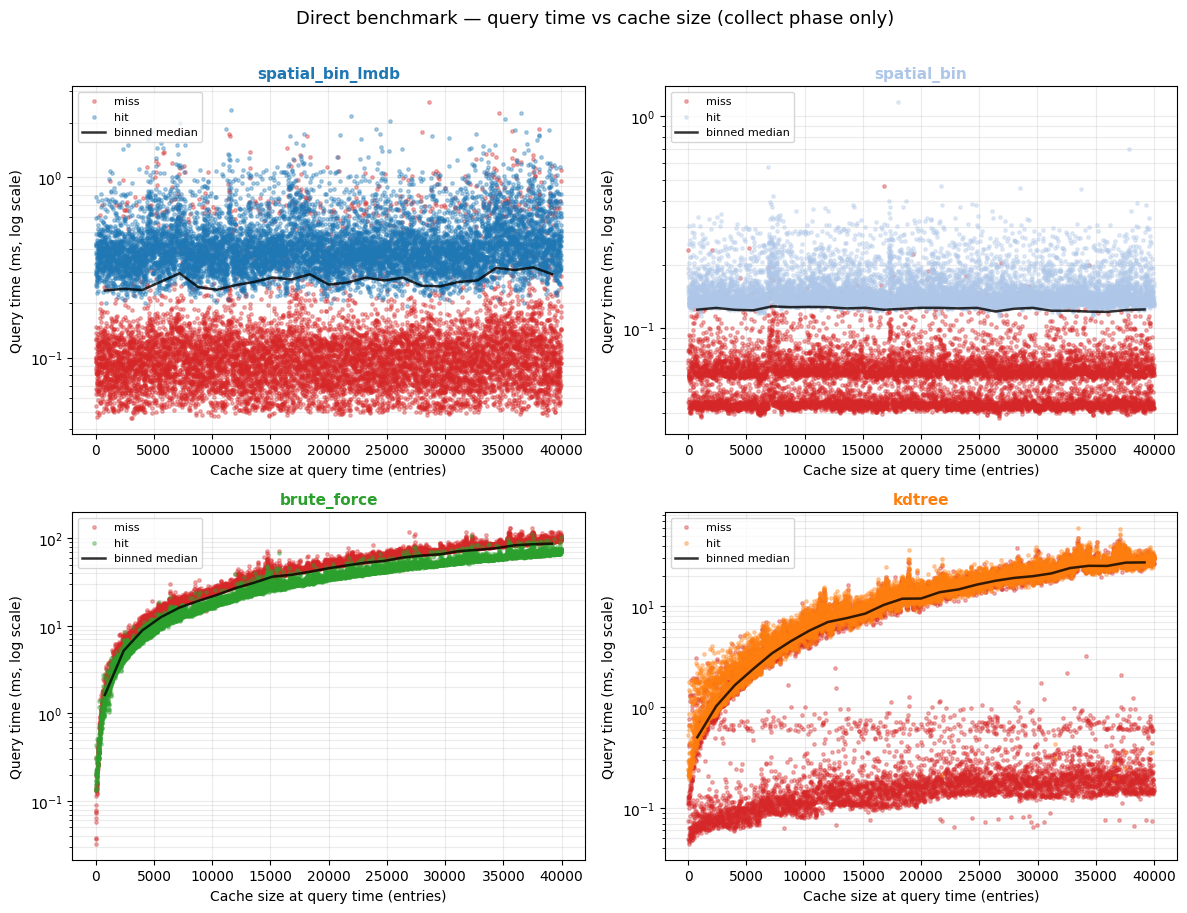

In [11]:
# Restrict to the collect phase so each leg lands at a distinct
# cache_size. Cycle-phase legs all sit at peak cache size and would
# pile up as a vertical stripe that distorts the binned median.
direct_collect = df_direct[df_direct["phase"] == "collect"]

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
axes = axes.flatten()

for ax, backend in zip(axes, BACKEND_ORDER):
    d = (
        direct_collect[direct_collect["backend"] == backend]
        .sort_values("cache_size_before")
        .reset_index(drop=True)
    )
    color = BACKEND_COLORS[backend]

    hit_mask = d["hit"] == True  # noqa: E712

    ax.scatter(
        d.loc[~hit_mask, "cache_size_before"],
        d.loc[~hit_mask, "query_time_ms"],
        s=6,
        alpha=0.35,
        color="#d62728",
        label="miss",
        zorder=2,
    )
    ax.scatter(
        d.loc[hit_mask, "cache_size_before"],
        d.loc[hit_mask, "query_time_ms"],
        s=6,
        alpha=0.35,
        color=color,
        label="hit",
        zorder=3,
    )

    if d["cache_size_before"].nunique() >= 5:
        bins = pd.cut(d["cache_size_before"], bins=25, include_lowest=True)
        binned = d.groupby(bins, observed=True)["query_time_ms"].median()
        centers = [iv.mid for iv in binned.index]
        ax.plot(
            centers,
            binned.values,
            color="black",
            lw=1.8,
            alpha=0.8,
            zorder=5,
            label="binned median",
        )

    ax.set_yscale("log")
    ax.set_title(backend, fontsize=11, color=color, fontweight="bold")
    ax.set_xlabel("Cache size at query time (entries)")
    ax.set_ylabel("Query time (ms, log scale)")
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle(
    "Direct benchmark — query time vs cache size (collect phase only)",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "plot6.png"), bbox_inches="tight")
plt.show()

**Takeaway.** With ~40 000 entries — far more than the planning benchmark
could reach — the asymptotic complexity classes become clearly visible:

- `spatial_bin_lmdb` and `spatial_bin` stay flat — O(1) bin-hash lookup
  confirmed (power exponents ≈ 0). The in-memory `spatial_bin` variant
  sits noticeably lower (median ~0.14 ms across all hits) than
  `spatial_bin_lmdb` (~0.31 ms) due to LMDB transaction overhead on each
  read.
- `brute_force`'s median climbs with a power exponent of ~+1.02,
  consistent with its O(N·d) full scan. At peak cache size (last binned
  median, ~39 000 entries) query time reaches **~78 ms** — over **530×
  slower** than `spatial_bin` at the same point.
- `kdtree`'s power exponent is approximately −0.79, reflecting that its
  amortized per-query cost *decreases* as N grows: the O(N log N) lazy
  rebuild is paid once per insert and is then amortized across all
  subsequent queries. Between rebuilds, queries are fast; the first query
  after each insert carries the spike visible in the scatter.

## Plot 7 — Update time vs cache size (direct benchmark, misses only)

`update_time_s` is recorded only on misses (hits don't write). Plotted
against the cache size *before* the insert, again per-backend on
log-y. This is the cost half of the cache's amortized analysis: how
expensive does a new insert get as the index grows?


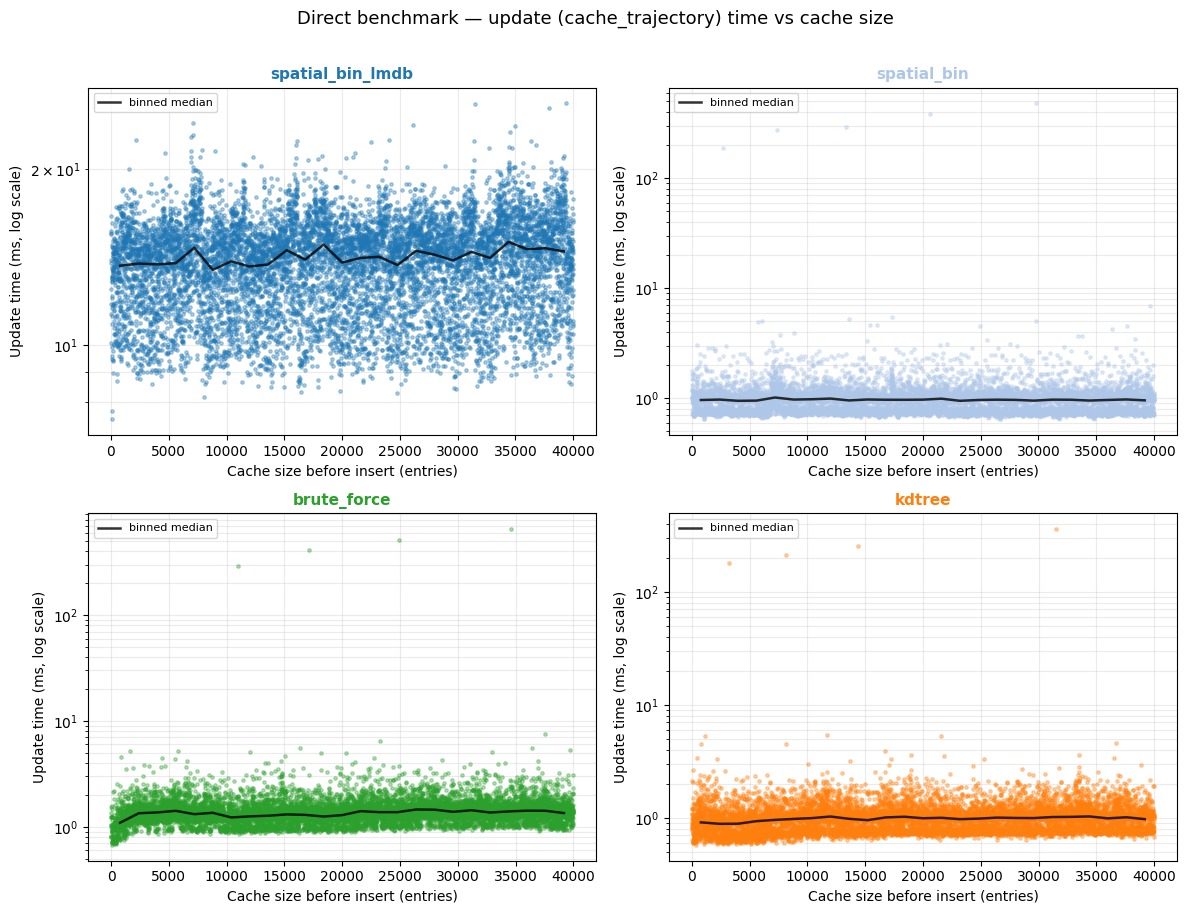

In [12]:
# Filter to misses-only (only misses do an insert) and to the collect
# phase so cache_size_before sweeps the full range.
misses = df_direct[
    (df_direct["hit"] == False) & (df_direct["phase"] == "collect")  # noqa: E712
].copy()

fig, axes = plt.subplots(2, 2, figsize=(12, 9), sharex=False)
axes = axes.flatten()

for ax, backend in zip(axes, BACKEND_ORDER):
    d = (
        misses[misses["backend"] == backend]
        .sort_values("cache_size_before")
        .reset_index(drop=True)
    )
    color = BACKEND_COLORS[backend]

    ax.scatter(
        d["cache_size_before"],
        d["update_time_ms"],
        s=6,
        alpha=0.35,
        color=color,
        zorder=3,
    )

    if d["cache_size_before"].nunique() >= 5:
        bins = pd.cut(d["cache_size_before"], bins=25, include_lowest=True)
        binned = d.groupby(bins, observed=True)["update_time_ms"].median()
        centers = [iv.mid for iv in binned.index]
        ax.plot(
            centers,
            binned.values,
            color="black",
            lw=1.8,
            alpha=0.8,
            zorder=5,
            label="binned median",
        )

    ax.set_yscale("log")
    ax.set_title(backend, fontsize=11, color=color, fontweight="bold")
    ax.set_xlabel("Cache size before insert (entries)")
    ax.set_ylabel("Update time (ms, log scale)")
    ax.grid(alpha=0.25, which="both")
    ax.legend(fontsize=8, loc="upper left")

fig.suptitle(
    "Direct benchmark — update (cache_trajectory) time vs cache size",
    fontsize=13,
    y=1.01,
)
plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "plot7.png"), bbox_inches="tight")
plt.show()

**Takeaway.** Insert cost is near-constant for every backend (power
exponents all < 0.05), confirming that the cache's amortized write cost
does not scale with N. The backends differ significantly in their
*absolute* insert latency, however:

- `spatial_bin` (~1.0 ms) and `kdtree` (~1.0 ms) are fastest: both
  perform an in-memory bisect-insort with no disk I/O per call.
- `brute_force` (~1.3 ms) is slightly slower due to serializing and
  storing the full trajectory bytes.
- `spatial_bin_lmdb` (~14 ms) is an order of magnitude slower: every
  insert commits a write transaction, which incurs an fsync when
  `sync=True`. This constant overhead is the price of durability — the
  cache survives process crashes without data loss.

The cache's total time budget is therefore dominated by the *query* path
at large N for `brute_force`, but by the *update* path for
`spatial_bin_lmdb` regardless of size.

## Plot 8 — Cumulative throughput (direct benchmark)

Total wall-clock spent in cache operations as the benchmark
progresses. This is the practical view: at the end of the run, how
many seconds did each backend spend serving queries + writing new
entries?


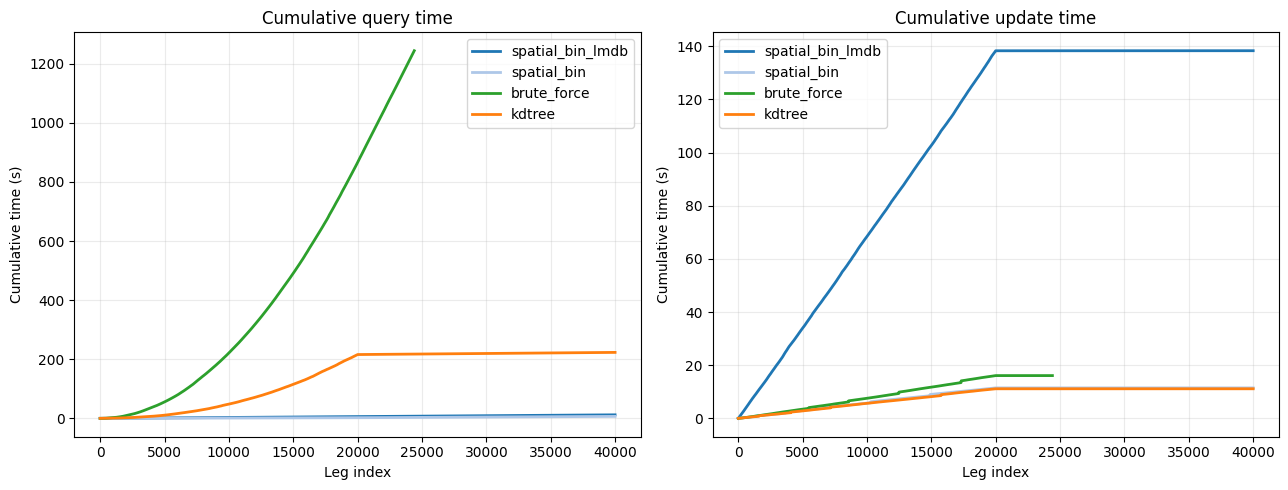

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for backend in BACKEND_ORDER:
    d = df_direct[df_direct["backend"] == backend].reset_index(drop=True)
    cum_q = d["query_time_s"].fillna(0).cumsum()
    cum_u = d["update_time_s"].fillna(0).cumsum()
    axes[0].plot(
        d.index + 1, cum_q, label=backend, color=BACKEND_COLORS[backend], lw=2
    )
    axes[1].plot(
        d.index + 1, cum_u, label=backend, color=BACKEND_COLORS[backend], lw=2
    )

for ax, title in zip(
    axes, ["Cumulative query time", "Cumulative update time"]
):
    ax.set_xlabel("Leg index")
    ax.set_ylabel("Cumulative time (s)")
    ax.set_title(title)
    ax.grid(alpha=0.25)
    ax.legend()

plt.tight_layout()
plt.savefig(os.path.join(FIGURE_DIR, "plot8.png"), bbox_inches="tight")
plt.show()

**Takeaway.** Cumulative query time fans out sharply between backends as
`cache_size` grows — `brute_force`'s slope steepens visibly since each
query gets more expensive, while `spatial_bin_lmdb` and `spatial_bin`
stay on a straight line (their per-query cost is independent of size).
Cumulative update time stays much more parallel across backends because
every backend's insert is roughly constant-cost per call.

## Direct benchmark — summary table


In [14]:
def power_fit(x: np.ndarray, y: np.ndarray) -> tuple[float, float]:
    """Fit y = a * x**b via log-log linear regression. Returns (a, b)."""
    mask = (x > 0) & (y > 0)
    if mask.sum() < 3:
        return float("nan"), float("nan")
    lx = np.log(x[mask])
    ly = np.log(y[mask])
    b, log_a = np.polyfit(lx, ly, 1)
    return float(np.exp(log_a)), float(b)


rows = []
for backend in BACKEND_ORDER:
    d = df_direct[df_direct["backend"] == backend]
    hits = d[d["hit"] == True]  # noqa: E712
    misses = d[d["hit"] == False]  # noqa: E712

    _, q_exp = power_fit(
        hits["cache_size_before"].to_numpy(),
        hits["query_time_s"].to_numpy(),
    )
    _, u_exp = power_fit(
        misses["cache_size_before"].to_numpy(),
        misses["update_time_s"].to_numpy(),
    )

    rows.append(
        {
            "backend": backend,
            "legs": len(d),
            "peak_cache_size": int(d["cache_size_after"].max()),
            "hit_rate_pct": 100 * d["hit"].mean(),
            "median_query_us": 1e6 * hits["query_time_s"].median()
            if len(hits)
            else float("nan"),
            "median_update_us": 1e6 * misses["update_time_s"].median()
            if len(misses)
            else float("nan"),
            "query_exponent": q_exp,
            "update_exponent": u_exp,
        }
    )

direct_summary = pd.DataFrame(rows)
direct_summary["backend"] = pd.Categorical(
    direct_summary["backend"], categories=BACKEND_ORDER, ordered=True
)
direct_summary = direct_summary.sort_values("backend").reset_index(drop=True)
direct_summary.style.format(
    {
        "hit_rate_pct": "{:.1f}%",
        "median_query_us": "{:.2f}",
        "median_update_us": "{:.2f}",
        "query_exponent": "{:+.3f}",
        "update_exponent": "{:+.3f}",
    }
)

,backend,legs,peak_cache_size,hit_rate_pct,median_query_us,median_update_us,query_exponent,update_exponent
0,spatial_bin_lmdb,40000,40006,75.0%,305.41,14092.37,-0.166,+0.015
1,spatial_bin,40000,40006,75.0%,143.10,965.36,+0.097,-0.005
2,brute_force,24402,39980,59.0%,51512.25,1341.72,+1.017,+0.045
3,kdtree,40000,39980,75.0%,414.14,980.51,-0.794,+0.024


In [15]:
# Verification: every numeric value cited in the Part 2 analysis,
# computed directly from the dataframe.

print("=" * 60)
print("Cycle-phase hit rate (Part 2 intro / Cell 26)")
print("=" * 60)
cyc_d = df_direct[df_direct.phase == "cycle"]
for b in BACKEND_ORDER:
    sub = cyc_d[cyc_d.backend == b]
    rate = (sub["hit"] == True).sum() / len(sub) * 100  # noqa: E712
    print(f"  {b}: {rate:.2f}%")

print()
print("=" * 60)
print("Median query time (HITS only), all phases (Plot 6 / Cell 30 / 40)")
print("=" * 60)
for b in BACKEND_ORDER:
    hits = df_direct[
        (df_direct.backend == b) & (df_direct["hit"] == True)  # noqa: E712
    ]
    print(f"  {b}: median={hits['query_time_ms'].median():.3f} ms")

print()
print("=" * 60)
print("Power exponent (log query_time vs log cache_size, HITS) — Plot 6")
print("=" * 60)
for b in BACKEND_ORDER:
    sub = df_direct[
        (df_direct.backend == b)
        & (df_direct["hit"] == True)  # noqa: E712
        & (df_direct.cache_size_before > 0)
        & (df_direct.query_time_ms > 0)
    ]
    x = np.log(sub["cache_size_before"])
    y = np.log(sub["query_time_ms"])
    coef = np.polyfit(x, y, 1)
    print(f"  {b}: exponent={coef[0]:+.3f}")

print()
print("=" * 60)
print(
    "Binned median query time at PEAK cache size (last of 25 bins) — Plot 6 / Cell 30"
)
print("=" * 60)
last_bin_medians = {}
for b in BACKEND_ORDER:
    sub = df_direct[
        (df_direct.backend == b) & (df_direct["hit"] == True)  # noqa: E712
    ].copy()
    bins = pd.cut(sub["cache_size_before"], bins=25, include_lowest=True)
    binned = sub.groupby(bins, observed=True)["query_time_ms"].median()
    first = binned.iloc[0]
    last = binned.iloc[-1]
    last_bin_medians[b] = last
    last_center = binned.index[-1].mid
    print(
        f"  {b}: first-bin median={first:.3f} ms, "
        f"last-bin median={last:.3f} ms (size~{last_center:.0f})"
    )
print(
    f"\n  brute_force / spatial_bin at peak: "
    f"{last_bin_medians['brute_force'] / last_bin_medians['spatial_bin']:.0f}× slower"
)

print()
print("=" * 60)
print("Median update time (MISSES only) — Plot 7 / Cell 33 / 40")
print("=" * 60)
for b in BACKEND_ORDER:
    misses = df_direct[
        (df_direct.backend == b) & (df_direct["hit"] == False)  # noqa: E712
    ]
    print(f"  {b}: median={misses['update_time_ms'].median():.3f} ms")

print()
print("=" * 60)
print("Power exponent (log update_time vs log cache_size, MISSES) — Plot 7")
print("=" * 60)
for b in BACKEND_ORDER:
    sub = df_direct[
        (df_direct.backend == b)
        & (df_direct["hit"] == False)  # noqa: E712
        & (df_direct.cache_size_before > 0)
        & (df_direct.update_time_ms > 0)
    ]
    x = np.log(sub["cache_size_before"])
    y = np.log(sub["update_time_ms"])
    coef = np.polyfit(x, y, 1)
    print(f"  {b}: exponent={coef[0]:+.3f}")

Cycle-phase hit rate (Part 2 intro / Cell 26)
  spatial_bin_lmdb: 100.00%
  spatial_bin: 100.00%
  brute_force: 100.00%
  kdtree: 100.00%

Median query time (HITS only), all phases (Plot 6 / Cell 30 / 40)
  spatial_bin_lmdb: median=0.305 ms
  spatial_bin: median=0.143 ms
  brute_force: median=51.512 ms
  kdtree: median=0.414 ms

Power exponent (log query_time vs log cache_size, HITS) — Plot 6
  spatial_bin_lmdb: exponent=-0.166
  spatial_bin: exponent=+0.097
  brute_force: exponent=+1.017
  kdtree: exponent=-0.794

Binned median query time at PEAK cache size (last of 25 bins) — Plot 6 / Cell 30
  spatial_bin_lmdb: first-bin median=0.371 ms, last-bin median=0.199 ms (size~39206)
  spatial_bin: first-bin median=0.139 ms, last-bin median=0.146 ms (size~39206)
  brute_force: first-bin median=1.399 ms, last-bin median=77.555 ms (size~39180)
  kdtree: first-bin median=0.663 ms, last-bin median=0.316 ms (size~39180)

  brute_force / spatial_bin at peak: 530× slower

Median update time (MISSES

The `query_exponent` is the slope of `log(query_time)` vs
`log(cache_size)`. Interpretation:

- ≈ 0 → `O(1)`: cost independent of size (hash-based).
- ≈ 1 → `O(N)`: cost linear in size (full scan).
- < 0 → sub-O(1) amortized: cost *decreases* with size, as a fixed
  setup cost (e.g. tree rebuild) is amortized across more queries.

`update_exponent` is the same metric for the insert path. Expect
near-zero for every backend since every insert path is a small
constant amount of work.

## Conclusions — direct benchmark

Decoupling the cache benchmark from MoveIt makes the asymptotic
behavior of each backend directly observable at ~40 000 entries:

1. **`spatial_bin_lmdb` and `spatial_bin` are O(1) for queries.**
   Power exponents land near 0 (−0.17 and +0.10 respectively); per-query
   latency holds steady at ~0.30 ms and ~0.14 ms through tens of
   thousands of entries. `spatial_bin` is faster because it avoids the
   LMDB read transaction overhead on each lookup.
2. **`brute_force` is O(N·d) as theorized.** Power exponent ≈ +1.02;
   at peak cache size (last binned median) query latency reaches
   **~78 ms** — over **530× slower** than `spatial_bin` at the same N.
   This confirms it as the baseline that any indexed structure should
   beat.
3. **`kdtree` shows sub-O(1) amortized query scaling** (exponent ≈ −0.79).
   The O(N log N) rebuild cost, paid once per insert, is amortized across
   all subsequent queries between inserts. The first query after each
   insert carries a spike visible in the scatter, but the median remains
   low (~0.41 ms overall) and the binned median actually *falls* from
   ~0.66 ms at low N to ~0.32 ms at peak N as rebuilds are amortized
   over more queries.
4. **Updates are near-constant for three backends; `spatial_bin_lmdb`
   is the exception.** `spatial_bin` (~0.97 ms), `kdtree` (~0.98 ms),
   and `brute_force` (~1.34 ms) all insert with flat scaling (exponents
   all < 0.05). `spatial_bin_lmdb` pays ~14 ms per insert for LMDB write
   transactions (fsync) — the cost of crash-durable persistence.
5. **The right choice depends on the persistence requirement.** For
   in-memory caching where durability is handled externally, `kdtree`
   gives sub-linear amortized query scaling with exact recall. If
   on-disk durability is required without sacrificing O(1) query time,
   `spatial_bin_lmdb` is viable — but its ~14 ms insert cost should be
   weighed against the frequency of new trajectories in the target
   workload.